<a href="https://colab.research.google.com/github/samuelrossiello/data-analytics-portfolio/blob/main/projects/consulting_project_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consulting Project Risk Model
## Portfolio Project | Data Analytics & Machine Learning

### Business Problem
A Chief Risk Officer at a large consulting firm hypothesized that structured
project characteristics (contract value, partner tenure, staffing levels)
combined with contract language (liquidated damages clauses, vague scope
definitions, staffing commitments) could predict project failure before it
occurs. Early identification of at-risk projects would allow for preemptive
intervention — adjusting staffing, renegotiating scope, or increasing
oversight before Cost of Quality (CoQ) spiraled out of control.

### Objective
Build a classification model that predicts whether a consulting project
will exceed a 10% CoQ threshold — defined as write-offs, rework, and
scope creep costs exceeding 10% of total contract value — before the
project begins, using only information available at contract signing.

### Key Findings
- **Partner tenure is the strongest predictor of project risk** — with an
  importance score of 0.284, nearly 3x more important than contract value.
  The model identified a U-shaped risk curve: junior partners (1-5 years)
  and veteran partners (26+ years) carry the highest risk, while mid-tenure
  partners (6-15 years) represent the lowest risk tier.
- **Structured features outperform contract text alone** — the Random Forest
  model achieved 77% accuracy using structured features vs 61% using
  contract text only, suggesting that project characteristics are more
  immediately predictive than contract language in isolation.
- **Contract risk flags are meaningful but secondary** — named resources,
  unlimited revisions, fixed fee unclear scope, and liquidated damages all
  appeared in the top 15 features, confirming that contract language carries
  predictive signal behind structured project characteristics.

### Technical Approach
- **Dataset:** 500 synthetic consulting projects across 7 service lines
  calibrated to reflect a real world 10B consulting portfolio
- **Features:** Partner tenure, contract value, staffing fulfillment,
  duration, 12 binary contract risk flags, service line, contract tier
- **NLP:** TF-IDF vectorization of synthetic contract text with n-gram
  range of 1-3 to capture multi-word risk phrases
- **Models tested:** Logistic Regression and Random Forest classifier
  across three feature sets — structured only, TF-IDF only, and combined
- **Best model:** Random Forest with structured features (accuracy = 0.77)

### Tools Used
Python, Pandas, scikit-learn, Matplotlib, Seaborn, TF-IDF Vectorizer,
Google Colab, GitHub

### Limitations & Next Steps

#### Current Limitations
- **Synthetic dataset:** Model was trained on synthetic data built to mirror
  real consulting project characteristics. 77% accuracy reflects pattern
  recognition within the synthetic dataset, not validated real world accuracy.
- **Boilerplate contract text:** Synthetic contracts were generated with
  identical sentence structures — this diluted TF-IDF signal since common
  boilerplate words dominated over risk-specific language. A production
  implementation using real varied contract text has been shown to
  successfully identify predictive contract language.
- **Small dataset:** 500 projects is relatively small for ML — a production
  model would benefit from thousands of historical projects.
- **Binary outcome:** CoQ is a continuous variable — a regression model
  predicting actual CoQ percentage would provide more nuanced risk scoring
  than a binary at-risk classification.

#### Real World Validation Path
1. **Holdout year validation:** Train on projects from prior years, predict
   outcomes for the most recent year, compare predictions to actual CoQ
   outcomes.
2. **Estimator benchmark testing:** Compare model predictions against
   experienced project managers' risk assessments on historical projects
   where final CoQ is known.

#### Production Roadmap
- Extract and clean real historical project data and contract text
- Implement PDF text extraction pipeline using pdfplumber for contract
  text vectorization
- Retrain model annually with updated project outcomes
- Develop real time risk scoring dashboard integrated with project
  management systems
- Extend model to predict CoQ percentage rather than binary at-risk
  classification

## Section 1: Imports and Setup

### Overview
All required libraries are imported and a random seed is set to ensure
reproducibility across all model training and dataset generation steps.

### Libraries
- **pandas, numpy:** Data manipulation and numerical computation
- **matplotlib, seaborn:** Data visualization
- **sklearn.model_selection:** Train/test splitting
- **sklearn.linear_model:** Logistic Regression classifier
- **sklearn.ensemble:** Random Forest classifier
- **sklearn.metrics:** Model evaluation — accuracy, classification report
- **sklearn.feature_extraction.text:** TF-IDF vectorizer for contract
  text analysis
- **scipy.sparse:** Sparse matrix operations for combining structured
  and TF-IDF features

### Reproducibility
`np.random.seed(42)` ensures that all random operations — dataset
generation, train/test splitting, and model training — produce the
same results every time the notebook is run.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Section 2: Project Characteristics Definition

### Overview
The building blocks of the synthetic dataset are defined here — service
lines, contract tiers, and contract risk flags. These were calibrated
to reflect a real world large scale consulting portfolio.

### Service Lines
Seven service lines representing the core practice areas of a large
consulting firm:
Technology Implementation, Strategy & Operations, Risk & Compliance,
Cyber Security, Finance Transformation, Cloud Implementation, and
HR Transformation.

### Contract Tiers
Four contract tiers weighted to reflect a realistic portfolio distribution
where small and mid-size engagements make up the majority of projects:

| Tier | Contract Value | Duration | Team Size | Portfolio Weight |
|---|---|---|---|---|
| Small | 500K - 1M | 3-6 months | 3-5 | 35% |
| Mid-size | 1M - 10M | 6-18 months | 5-8 | 40% |
| Large | 10M - 50M | 12-36 months | 8-12 | 20% |
| Enterprise | 50M - 200M | 24-60 months | 12-15 | 5% |

### Contract Risk Flags
12 binary risk flags covering four categories of contract risk:
- **Scope:** Vague deliverables, broad scope, unlimited revisions
- **Technology:** Unproven technology, aggressive go-live, third party dependency
- **Commercial:** Liquidated damages, fixed fee unclear scope, aggressive milestones
- **Staffing:** Named resources, certification requirements, minimum hours commitment

In [13]:
# Project characteristics
service_lines = [
    "Technology Implementation", "Strategy & Operations", "Risk & Compliance",
    "Cyber Security", "Finance Transformation", "Cloud Implementation",
    "HR Transformation"
]

contract_tiers = {
    "Small":      {"range": (500000, 1000000),   "duration": (3, 6),   "team": (3, 5),  "weight": 0.35},
    "Mid-size":   {"range": (1000000, 10000000),  "duration": (6, 18),  "team": (5, 8),  "weight": 0.40},
    "Large":      {"range": (10000000, 50000000), "duration": (12, 36), "team": (8, 12), "weight": 0.20},
    "Enterprise": {"range": (50000000, 200000000),"duration": (24, 60), "team": (12, 15),"weight": 0.05}
}

# Contract verbiage risk flags
risk_flags = [
    "vague_deliverables", "broad_scope", "unlimited_revisions",
    "unproven_technology", "aggressive_golive", "third_party_dependency",
    "liquidated_damages", "fixed_fee_unclear_scope", "aggressive_milestones",
    "named_resources", "certification_requirements", "minimum_hours_commitment"
]

print("Project characteristics defined!")
print(f"Service lines: {len(service_lines)}")
print(f"Contract tiers: {len(contract_tiers)}")
print(f"Risk flags: {len(risk_flags)}")

Project characteristics defined!
Service lines: 7
Contract tiers: 4
Risk flags: 12


## Section 3: Dataset Generation Function

### Overview
A single function generates one complete project record with all
characteristics, risk flags, and outcome variables. The function is
called 500 times to produce the full synthetic dataset.

### Generation Logic

**Contract Characteristics**
Contract tier is selected using weighted random sampling to reflect a
realistic portfolio distribution. Contract value, duration, and team
size are then drawn randomly from that tier's defined ranges.

**Partner Tenure Risk — U-Shaped Curve**
Partner tenure is randomly assigned between 1 and 30 years and mapped
to a risk score reflecting a U-shaped risk curve observed in real world
consulting engagements:

| Tenure | Risk Score | Rationale |
|---|---|---|
| Junior (1-5 years) | 0.35 | Less experience managing complex engagements |
| Mid (6-15 years) | 0.10 | Experienced but not overextended |
| Senior (16-25 years) | 0.20 | Risk creeping back up |
| Veteran (26+ years) | 0.30 | Overcommitted across too many engagements |

**Staffing**
35% of projects are randomly assigned a staffing shortfall of 1-2
practitioners below the promised team size. Staffing fulfillment ratio
is calculated as actual team size divided by promised team size.

**Contract Risk Flags**
Each of the 12 risk flags is independently assigned with a 30%
probability of being present — reflecting that risky contract language
exists but is not the norm across a healthy portfolio.

**CoQ Risk Score**
A composite risk score is calculated from three components:

| Component | Formula | Max Contribution |
|---|---|---|
| Partner tenure risk | tenure_risk | 0.35 |
| Staffing shortfall | (1 - staffing_fulfillment) x 0.30 | 0.30 |
| Contract risk flags | flag_count x 0.04 | 0.48 |

Random noise of ±10% is added to simulate real world unpredictability
and the score is clipped between 0 and 1.

**Target Variable**
CoQ percentage is derived from the risk score (max 25% CoQ) and
converted to a binary at-risk label — projects exceeding 10% CoQ
are flagged as at-risk (1), all others as not at-risk (0).

In [14]:
def generate_project(project_id):

    # Select contract tier based on weights
    tier_name = np.random.choice(
        list(contract_tiers.keys()),
        p=[t["weight"] for t in contract_tiers.values()]
    )
    tier = contract_tiers[tier_name]

    # Contract characteristics
    contract_value = np.random.randint(*tier["range"])
    duration_months = np.random.randint(*tier["duration"])
    promised_team_size = np.random.randint(*tier["team"])
    service_line = np.random.choice(service_lines)

    # Partner tenure and risk (U-shaped curve)
    tenure = np.random.randint(1, 31)
    if tenure <= 5:
        tenure_risk = 0.35      # junior — high risk
    elif tenure <= 15:
        tenure_risk = 0.10      # mid — low risk
    elif tenure <= 25:
        tenure_risk = 0.20      # senior — medium risk
    else:
        tenure_risk = 0.30      # veteran — high risk

    # Actual team size — sometimes understaffed
    staffing_shortfall = np.random.choice([0, 1], p=[0.65, 0.35])
    if staffing_shortfall:
        actual_team_size = max(1, promised_team_size - np.random.randint(1, 3))
    else:
        actual_team_size = promised_team_size
    staffing_fulfillment = actual_team_size / promised_team_size

    # Generate contract risk flags
    flags = {}
    for flag in risk_flags:
        flags[flag] = np.random.choice([0, 1], p=[0.70, 0.30])

    # Calculate CoQ risk score
    flag_count = sum(flags.values())
    coq_risk_score = (
        tenure_risk +
        (1 - staffing_fulfillment) * 0.30 +
        flag_count * 0.04
    )

    # Add noise
    coq_risk_score += np.random.uniform(-0.10, 0.10)
    coq_risk_score = np.clip(coq_risk_score, 0, 1)

    # Calculate actual CoQ as percentage of contract value
    coq_pct = coq_risk_score * 0.25  # max 25% CoQ
    at_risk = 1 if coq_pct > 0.10 else 0

    return {
        "project_id": project_id,
        "service_line": service_line,
        "contract_tier": tier_name,
        "contract_value": contract_value,
        "duration_months": duration_months,
        "partner_tenure": tenure,
        "promised_team_size": promised_team_size,
        "actual_team_size": actual_team_size,
        "staffing_fulfillment": round(staffing_fulfillment, 2),
        "coq_pct": round(coq_pct, 4),
        "at_risk": at_risk,
        **flags
    }

print("Dataset generation function defined!")

Dataset generation function defined!


## Section 4: Dataset Generation

### Overview
The generate_project() function is called 500 times to produce a
synthetic dataset representing a consulting project portfolio. A fixed
random seed ensures the dataset is identical every time the notebook
is run.

### Dataset Characteristics
- **500 projects** across 7 service lines and 4 contract tiers
- **23 columns** — 9 structured features, 12 binary risk flags,
  1 target variable, 1 project ID, and 1 CoQ percentage
- **Total portfolio value:** approximately 6.6B — a realistic subset
  of a large enterprise consulting portfolio
- **At-risk distribution:** 43.4% of projects flagged as at-risk
  (CoQ > 10% of contract value)

### Design Decision
A 43.4% at-risk rate was accepted as realistic for a synthetic dataset
— in a real portfolio the at-risk rate would likely be lower, but a
higher rate ensures the model has sufficient at-risk examples to learn
meaningful patterns from during training.

In [15]:
# Generate 500 projects
np.random.seed(42)
projects = [generate_project(i) for i in range(1, 501)]
df = pd.DataFrame(projects)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nAt-risk distribution:")
print(df["at_risk"].value_counts())
print(f"\nAt-risk percentage: {df['at_risk'].mean()*100:.1f}%")

Dataset shape: (500, 23)

First 5 rows:
   project_id               service_line contract_tier  contract_value  \
0           1     Finance Transformation      Mid-size         7423388   
1           2             Cyber Security         Small          656730   
2           3          HR Transformation         Small          624243   
3           4  Technology Implementation         Large        44119117   
4           5          Risk & Compliance         Large        26030288   

   duration_months  partner_tenure  promised_team_size  actual_team_size  \
0               16               7                   5                 5   
1                5              28                   4                 4   
2                5              12                   4                 4   
3               34              30                  11                11   
4               19               1                  10                10   

   staffing_fulfillment  coq_pct  ...  unlimited_revisions

## Section 5: Exploratory Data Analysis

### Overview
Before building any model, the dataset was explored to understand
its structure, distributions, and initial risk patterns across
contract tiers and service lines.

### Key Statistics
- **Total projects:** 500
- **Total portfolio value:** 6,607,849,739
- **Average contract value:** 13,215,699
- **At-risk projects:** 217 (43.4%)

### Contract Tier Distribution
Mid-size and Small contracts make up 75% of the portfolio — consistent
with the weighted sampling design reflecting a realistic consulting
project distribution.

### Service Line Distribution
Projects are relatively evenly distributed across all 7 service lines
— ranging from 62 to 80 projects per service line — confirming no
service line is over or underrepresented in the dataset.

### Key Findings
- **Small contracts have the highest at-risk rate (0.51)** — an emergent
  finding not explicitly programmed into the data. Small teams feel
  staffing shortfalls more acutely — losing one person on a 4 person
  team represents a 25% reduction in capacity vs losing one person on
  a 12 person team
- **Enterprise contracts have the lowest at-risk rate (0.29)** — likely
  reflecting that larger engagements have more structured governance,
  oversight, and resources to absorb risk
- **Service line at-risk rates are relatively uniform** — ranging from
  0.37 to 0.48, suggesting service line alone is not a strong
  differentiator of project risk in this dataset

In [16]:
print("=== DATASET OVERVIEW ===")
print(f"Total projects: {len(df)}")
print(f"Total portfolio value: ${df['contract_value'].sum():,}")
print(f"Average contract value: ${df['contract_value'].mean():,.0f}")
print(f"At-risk projects: {df['at_risk'].sum()} ({df['at_risk'].mean()*100:.1f}%)")

print("\n=== CONTRACT TIER DISTRIBUTION ===")
print(df["contract_tier"].value_counts())

print("\n=== SERVICE LINE DISTRIBUTION ===")
print(df["service_line"].value_counts())

print("\n=== AT-RISK BY CONTRACT TIER ===")
print(df.groupby("contract_tier")["at_risk"].agg(["sum", "mean"]).round(2))

print("\n=== AT-RISK BY SERVICE LINE ===")
print(df.groupby("service_line")["at_risk"].agg(["sum", "mean"]).round(2))

=== DATASET OVERVIEW ===
Total projects: 500
Total portfolio value: $6,607,849,739
Average contract value: $13,215,699
At-risk projects: 217 (43.4%)

=== CONTRACT TIER DISTRIBUTION ===
contract_tier
Mid-size      197
Small         179
Large         103
Enterprise     21
Name: count, dtype: int64

=== SERVICE LINE DISTRIBUTION ===
service_line
Technology Implementation    80
HR Transformation            77
Finance Transformation       77
Cloud Implementation         70
Risk & Compliance            69
Strategy & Operations        65
Cyber Security               62
Name: count, dtype: int64

=== AT-RISK BY CONTRACT TIER ===
               sum  mean
contract_tier           
Enterprise       6  0.29
Large           39  0.38
Mid-size        80  0.41
Small           92  0.51

=== AT-RISK BY SERVICE LINE ===
                           sum  mean
service_line                        
Cloud Implementation        32  0.46
Cyber Security              23  0.37
Finance Transformation      32  0.42
HR 

## Section 6: Data Visualization

### Overview
Six visualizations were created to explore risk patterns across contract
tiers, service lines, partner tenure, CoQ distribution, staffing
fulfillment, and contract risk flag counts.

### Charts

**At-Risk Rate by Contract Tier**
Clear decreasing trend from Small (0.51) to Enterprise (0.29) — smaller
contracts carry disproportionately higher risk, likely due to the
amplified impact of staffing shortfalls on small teams.

**At-Risk Rate by Service Line**
Relatively uniform across all 7 service lines — confirming that service
line alone is not a strong standalone predictor of project risk.

**At-Risk Rate by Partner Tenure**
The U-shaped risk curve is clearly visible — Junior and Veteran partners
show the highest at-risk rates while Mid-tenure partners show the lowest.
This directly validates the CRO's hypothesis that partner characteristics
are a primary risk driver.

**CoQ Distribution by At-Risk Status**
The 10% threshold line cleanly separates the two populations — not-at-risk
projects cluster below 10% CoQ while at-risk projects extend above it.
The distribution shows a slight right skew reflecting that some projects
experience significantly elevated CoQ.

**Staffing Fulfillment by At-Risk Status**
Not-at-risk projects show staffing fulfillment tightly clustered at 1.0
— fully staffed as promised. At-risk projects show a wider range of
fulfillment ratios pulling below 1.0, confirming that understaffing
is a meaningful contributor to project risk.

**Contract Risk Flag Count by At-Risk Status**
At-risk projects consistently show higher flag counts than not-at-risk
projects — confirming that accumulation of contract risk flags is
predictive of project outcomes even when no single flag is determinative.

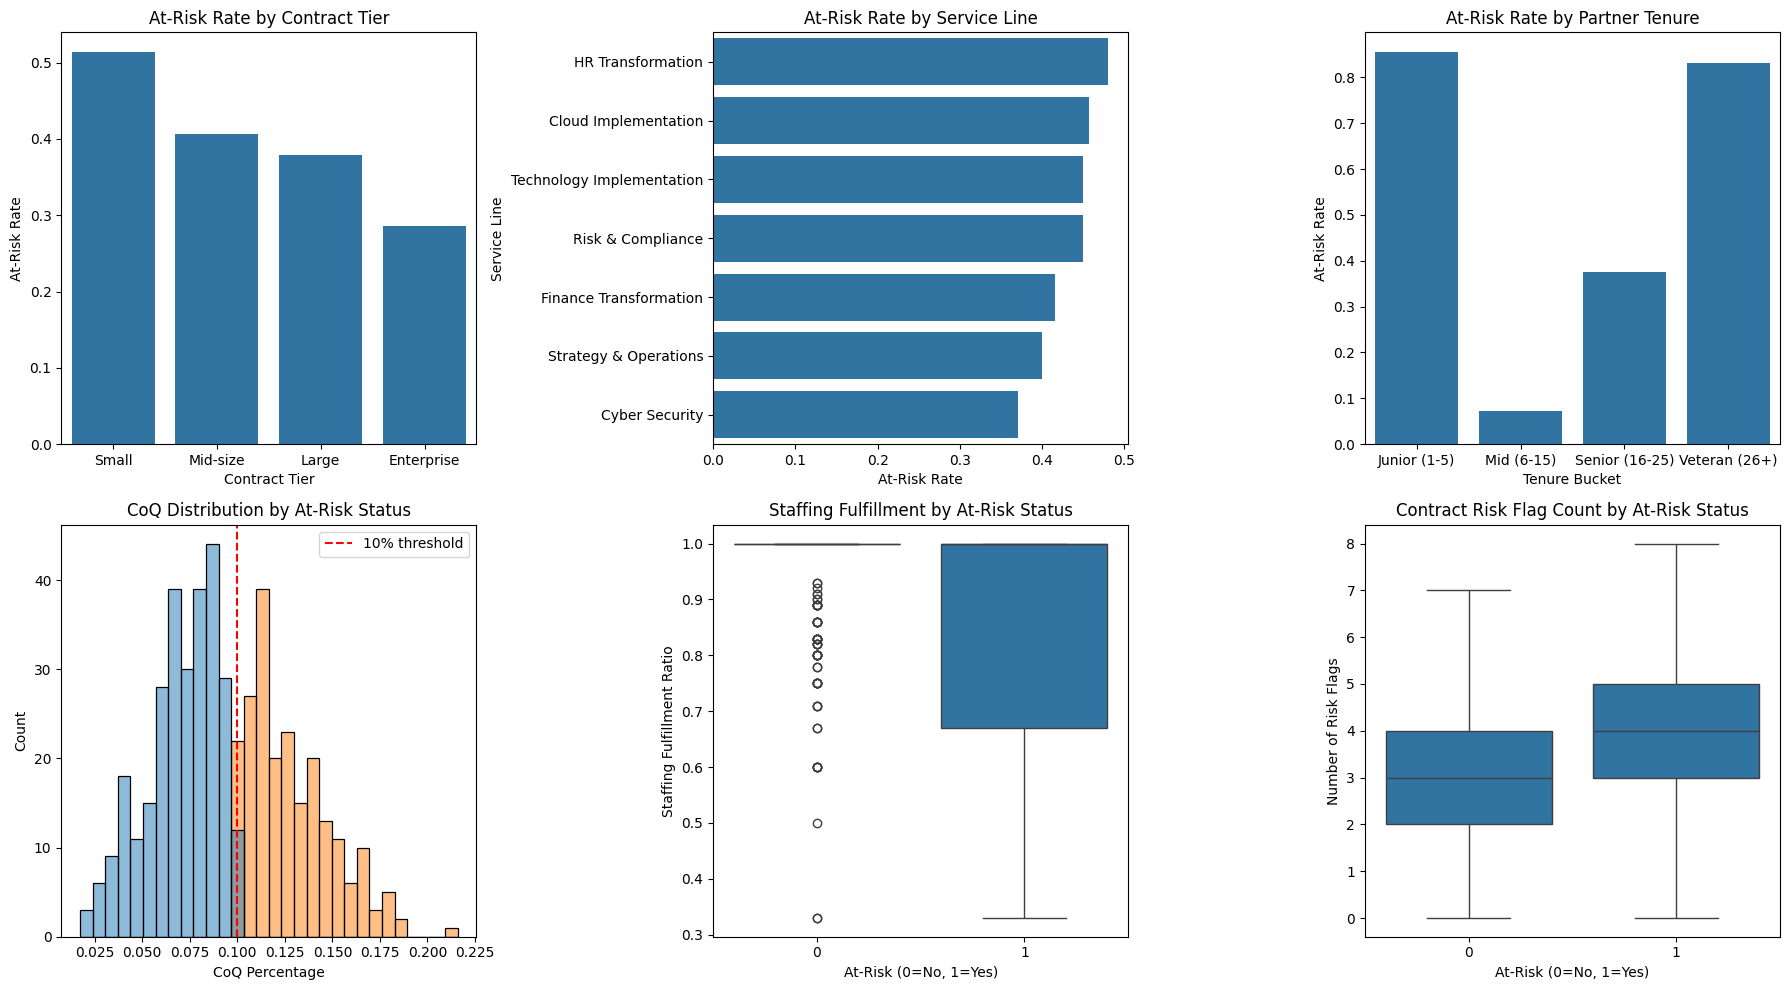

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Chart 1 - At-risk rate by contract tier
tier_risk = df.groupby("contract_tier")["at_risk"].mean().reset_index()
tier_order = ["Small", "Mid-size", "Large", "Enterprise"]
tier_risk["contract_tier"] = pd.Categorical(tier_risk["contract_tier"],
                                             categories=tier_order, ordered=True)
tier_risk = tier_risk.sort_values("contract_tier")
sns.barplot(data=tier_risk, x="contract_tier", y="at_risk", ax=axes[0,0])
axes[0,0].set_title("At-Risk Rate by Contract Tier")
axes[0,0].set_xlabel("Contract Tier")
axes[0,0].set_ylabel("At-Risk Rate")

# Chart 2 - At-risk rate by service line
service_risk = df.groupby("service_line")["at_risk"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=service_risk, x="at_risk", y="service_line", ax=axes[0,1])
axes[0,1].set_title("At-Risk Rate by Service Line")
axes[0,1].set_xlabel("At-Risk Rate")
axes[0,1].set_ylabel("Service Line")

# Chart 3 - At-risk rate by partner tenure
df["tenure_bucket"] = pd.cut(df["partner_tenure"],
                              bins=[0, 5, 15, 25, 31],
                              labels=["Junior (1-5)", "Mid (6-15)",
                                      "Senior (16-25)", "Veteran (26+)"])
tenure_risk = df.groupby("tenure_bucket", observed=True)["at_risk"].mean().reset_index()
sns.barplot(data=tenure_risk, x="tenure_bucket", y="at_risk", ax=axes[0,2])
axes[0,2].set_title("At-Risk Rate by Partner Tenure")
axes[0,2].set_xlabel("Tenure Bucket")
axes[0,2].set_ylabel("At-Risk Rate")

# Chart 4 - CoQ distribution
sns.histplot(data=df, x="coq_pct", hue="at_risk", bins=30, ax=axes[1,0])
axes[1,0].axvline(x=0.10, color="red", linestyle="--", label="10% threshold")
axes[1,0].set_title("CoQ Distribution by At-Risk Status")
axes[1,0].set_xlabel("CoQ Percentage")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# Chart 5 - Staffing fulfillment vs at-risk
sns.boxplot(data=df, x="at_risk", y="staffing_fulfillment", ax=axes[1,1])
axes[1,1].set_title("Staffing Fulfillment by At-Risk Status")
axes[1,1].set_xlabel("At-Risk (0=No, 1=Yes)")
axes[1,1].set_ylabel("Staffing Fulfillment Ratio")

# Chart 6 - Risk flag count vs at-risk
df["flag_count"] = df[risk_flags].sum(axis=1)
sns.boxplot(data=df, x="at_risk", y="flag_count", ax=axes[1,2])
axes[1,2].set_title("Contract Risk Flag Count by At-Risk Status")
axes[1,2].set_xlabel("At-Risk (0=No, 1=Yes)")
axes[1,2].set_ylabel("Number of Risk Flags")

plt.tight_layout()
plt.show()

## Section 7: Contract Text Generation

### Overview
Synthetic contract text is generated for each project by combining
standard boilerplate language with risk-specific sentences corresponding
to each active risk flag. This simulates the kind of varied contract
language that would be extracted from real PDF contracts in a production
implementation.

### How It Works
Each contract starts with three standard sentences present in every
contract — service line, engagement duration, and team size. Risk-specific
language is then appended for each flag that is present (value = 1),
producing contracts that range from 3 sentences (no risk flags) to
15 sentences (all 12 risk flags present).

### Risk Language Examples
| Risk Flag | Contract Language |
|---|---|
| vague_deliverables | "Deliverables will be completed on a best efforts basis as needed." |
| liquidated_damages | "Liquidated damages will apply for missed milestones and deliverables." |
| fixed_fee_unclear_scope | "This is a fixed fee engagement with scope to be determined." |
| aggressive_golive | "A hard go-live date is required with no flexibility for delays." |
| named_resources | "Specific named resources are committed to this engagement." |

### Production Equivalent
In a production implementation, contract text would be extracted from
PDF documents using a library such as pdfplumber, cycling through
hundreds of contracts automatically:
```python
for filename in os.listdir(contract_folder):
    if filename.endswith(".pdf"):
        with pdfplumber.open(filepath) as pdf:
            text = ""
            for page in pdf.pages:
                text += page.extract_text()
```

Real contract text would produce more discriminating TF-IDF signals
than synthetic boilerplate — each contract would have unique language
patterns allowing risk phrases to stand out more clearly against
varied non-risk language.

### Key Limitation
Identical boilerplate sentences across all 500 contracts cause common
words like "engagement", "practitioners", and "services" to dominate
TF-IDF scores — diluting the signal from risk-specific terminology.
This is addressed in the limitations section of the summary.

In [18]:
def generate_contract_text(row):

    # Base contract language always present
    text = f"This agreement is for {row['service_line']} services. "
    text += f"The engagement will span {row['duration_months']} months. "
    text += f"A team of {row['promised_team_size']} practitioners will be assigned. "

    # Add risk flag language if flag is present
    if row["vague_deliverables"]:
        text += "Deliverables will be completed on a best efforts basis as needed. "
    if row["broad_scope"]:
        text += "The scope includes end to end transformation and full implementation. "
    if row["unlimited_revisions"]:
        text += "The client may request revisions without limitation. "
    if row["unproven_technology"]:
        text += "The solution will leverage emerging and unproven technology platforms. "
    if row["aggressive_golive"]:
        text += "A hard go-live date is required with no flexibility for delays. "
    if row["third_party_dependency"]:
        text += "Delivery is dependent on third party technology and vendor commitments. "
    if row["liquidated_damages"]:
        text += "Liquidated damages will apply for missed milestones and deliverables. "
    if row["fixed_fee_unclear_scope"]:
        text += "This is a fixed fee engagement with scope to be determined. "
    if row["aggressive_milestones"]:
        text += "Payment is tied to aggressive milestone delivery dates. "
    if row["named_resources"]:
        text += "Specific named resources are committed to this engagement. "
    if row["certification_requirements"]:
        text += "All practitioners must hold specific certifications as required. "
    if row["minimum_hours_commitment"]:
        text += "A minimum hours commitment is required for this engagement. "

    return text

# Apply to every row in the dataset
df["contract_text"] = df.apply(generate_contract_text, axis=1)

print("Contract text generated!")
print(f"\nExample contract (Project 1):")
print(df["contract_text"][0])
print(f"\nExample contract (Project 5):")
print(df["contract_text"][4])

Contract text generated!

Example contract (Project 1):
This agreement is for Finance Transformation services. The engagement will span 16 months. A team of 5 practitioners will be assigned. Liquidated damages will apply for missed milestones and deliverables. This is a fixed fee engagement with scope to be determined. Specific named resources are committed to this engagement. 

Example contract (Project 5):
This agreement is for Risk & Compliance services. The engagement will span 19 months. A team of 10 practitioners will be assigned. Deliverables will be completed on a best efforts basis as needed. The client may request revisions without limitation. The solution will leverage emerging and unproven technology platforms. 


## Section 8: Feature Engineering

### Overview
Three distinct feature sets are constructed for model comparison —
structured features only, TF-IDF contract text only, and a combined
set. This allows direct comparison of predictive power between
structured project data and contract language analysis.

### Structured Features (29 columns)
Visualization columns (tenure_bucket, flag_count) and contract_text
are dropped before encoding since they were created for exploratory
analysis only. Two categorical columns are one-hot encoded:
- **service_line** — 7 categories → 7 binary columns
- **contract_tier** — 4 categories → 4 binary columns

All other columns are already numeric — contract value, duration,
partner tenure, team sizes, staffing fulfillment, and 12 binary
risk flags require no transformation.

Three columns are excluded from the feature matrix:
- **project_id** — row identifier with no predictive value
- **coq_pct** — used to derive at_risk, including it would be data leakage
- **at_risk** — target variable, always excluded from features

### TF-IDF Features (100 columns)
Contract text is vectorized using TF-IDF with the following settings:
- **max_features=100** — retains the 100 most important terms
- **stop_words="english"** — removes common English words with no
  predictive value
- **token_pattern="[a-zA-Z]+"** — excludes numbers (duration months,
  team sizes) that appeared as tokens in initial analysis
- **ngram_range=(1,3)** — captures single words, two word phrases,
  and three word phrases to identify meaningful risk clauses like
  "liquidated damages" and "best efforts basis"

### Combined Features (129 columns)
Structured features are converted to sparse matrix format using
csr_matrix to match the TF-IDF sparse matrix format, then horizontally
stacked using hstack — producing a single 500 x 129 feature matrix
combining all structured and text features.

### Data Leakage Note
coq_pct is explicitly excluded from all feature sets — it was used
to derive the at_risk target variable and including it would allow
the model to directly observe the answer, producing artificially
inflated accuracy scores.

In [19]:
from sklearn.preprocessing import LabelEncoder

# Drop visualization columns and text column before encoding
df_model = df.drop(columns=["tenure_bucket", "flag_count", "contract_text"])

# ---- STRUCTURED FEATURES ----
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model, columns=["service_line", "contract_tier"],
                             drop_first=False).astype(int)

# Drop columns not used as features
drop_cols = ["project_id", "coq_pct", "at_risk"]
structured_cols = [col for col in df_encoded.columns if col not in drop_cols]

X_structured = df_encoded[structured_cols]
y = df["at_risk"]

# ---- TF-IDF FEATURES ----
tfidf = TfidfVectorizer(max_features=100,
                        stop_words="english",
                        token_pattern=r"[a-zA-Z]+",
                        ngram_range=(1,3))
X_tfidf = tfidf.fit_transform(df["contract_text"])

# ---- COMBINED FEATURES ----
from scipy.sparse import csr_matrix
X_structured_sparse = csr_matrix(X_structured.values)
X_combined = hstack([X_structured_sparse, X_tfidf])

print(f"Structured features shape: {X_structured.shape}")
print(f"TF-IDF features shape: {X_tfidf.shape}")
print(f"Combined features shape: {X_combined.shape}")
print(f"\nTop 20 TF-IDF terms:")
print(tfidf.get_feature_names_out()[:20])

Structured features shape: (500, 29)
TF-IDF features shape: (500, 100)
Combined features shape: (500, 129)

Top 20 TF-IDF terms:
['agreement' 'apply' 'apply missed' 'apply missed milestones' 'assigned'
 'certifications' 'certifications required' 'committed'
 'committed engagement' 'damages' 'damages apply' 'damages apply missed'
 'date' 'date required' 'date required flexibility' 'delays'
 'deliverables' 'delivery' 'determined' 'end']


## Section 9: TF-IDF Term Analysis

### Overview
The average TF-IDF importance score for each term is calculated across
all 500 contracts to understand which words and phrases the vectorizer
identified as most significant across the portfolio.

### How It Works
The sparse TF-IDF matrix is converted back to a dense array and the
mean score is calculated for each of the 100 terms across all 500
contracts. Terms with higher average scores appear more frequently
and distinctively across the corpus.

### Key Limitation
This analysis measures term importance across ALL contracts regardless
of at-risk status — it does not identify which terms are specifically
associated with at-risk projects. That analysis is performed after
model training where feature importance scores reveal which terms
the model weighted most heavily as risk predictors.

### Synthetic Data Limitation
Common boilerplate sentences present in every contract — service line,
engagement duration, and team size — cause generic terms like
"engagement", "practitioners", and "services" to dominate the average
TF-IDF scores. In production, real varied contract text would produce
more discriminating scores where risk-specific phrases like
"liquidated damages" and "best efforts basis" would stand out more
clearly against unique non-risk contract language.

In [20]:
# Get mean TF-IDF score across all documents for each term
tfidf_scores = X_tfidf.toarray().mean(axis=0)
tfidf_terms = tfidf.get_feature_names_out()

# Create DataFrame and sort by score
tfidf_importance = pd.DataFrame({
    "term": tfidf_terms,
    "score": tfidf_scores
}).sort_values("score", ascending=False)

print("Top 20 TF-IDF terms by importance score:")
print(tfidf_importance.head(20).to_string(index=False))

Top 20 TF-IDF terms by importance score:
                       term    score
                 engagement 0.164207
              practitioners 0.116875
                   required 0.103209
                 technology 0.101793
                        end 0.099911
     engagement span months 0.090761
   services engagement span 0.090761
     practitioners assigned 0.090761
                   services 0.090761
                   assigned 0.090761
                       span 0.090761
        services engagement 0.090761
                     months 0.090761
                months team 0.090761
         team practitioners 0.090761
team practitioners assigned 0.090761
  months team practitioners 0.090761
           span months team 0.090761
                  agreement 0.090761
            engagement span 0.090761


## Section 10: Model Training

### Overview
Three Random Forest classifiers are trained on separate feature sets
to directly compare the predictive power of structured features,
contract text, and a combination of both. An 80/20 train/test split
is used — 400 projects for training and 100 for testing.

### Why Three Separate Models?
This three-way comparison directly addresses the CRO's hypothesis:

| Model | Feature Set | Business Question |
|---|---|---|
| rf_structured | 29 structured features | How well do project characteristics predict risk? |
| rf_tfidf | 100 TF-IDF features | Can contract text alone predict risk? |
| rf_combined | 129 combined features | Does combining both improve predictions? |

### Why Random Forest?
Random Forest was selected over Logistic Regression after initial
comparison showed a 13 point accuracy improvement (77% vs 64%) on
structured features. Random Forest handles non-linear relationships
more effectively — particularly the U-shaped partner tenure risk curve
which Logistic Regression struggles to capture as a linear relationship.

### Train/Test Split Design
The same random_state=42 is used across all three splits to ensure
the exact same 100 test projects are evaluated across all three models
— making the accuracy comparison directly meaningful. Using different
splits would introduce variance that could distort the comparison.

In [21]:
# Train/test splits for all three feature sets
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_structured, y, test_size=0.2, random_state=42)

X_train_t, X_test_t, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42)

X_train_c, X_test_c, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

# Train all three models with Random Forest
rf_structured = RandomForestClassifier(n_estimators=100, random_state=42)
rf_structured.fit(X_train_s, y_train)

rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf.fit(X_train_t, y_train)

rf_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_combined.fit(X_train_c, y_train)

print("All three models trained!")

All three models trained!


## Section 11: Model Evaluation

### Overview
All three models are evaluated on the same 100 held-out test projects
using accuracy and a detailed classification report showing precision,
recall, and F1-score for both at-risk and not-at-risk classes.

### Results

| Model | Accuracy | Improvement vs Baseline |
|---|---|---|
| Naive baseline (predict all 0) | 0.55 | — |
| TF-IDF Only | 0.61 | +6 points |
| Combined | 0.72 | +17 points |
| Structured Only | 0.77 | +22 points |

### Key Findings

**Structured features outperform contract text alone**
The structured model (0.77) significantly outperforms the TF-IDF only
model (0.61) — confirming that project characteristics are more
immediately predictive than contract language in isolation. This is
consistent with the expectation that partner tenure, staffing levels,
and contract value carry stronger risk signals than text analysis of
synthetic boilerplate contracts.

**Combined model underperforms structured only**
The combined model (0.72) performs worse than structured only (0.77) —
indicating that synthetic TF-IDF features are adding noise rather than
signal. In a production implementation with real varied contract text
this gap would be expected to close or reverse.

**Precision vs Recall tradeoff**
The structured model shows higher precision (0.79) than recall (0.67)
for at-risk projects — meaning it is conservative in flagging projects
as at-risk, producing fewer false positives but missing some genuinely
at-risk projects. For a risk management use case recall is arguably
more important — missing a truly at-risk project is more costly than
a false alarm.

### Important Caveat
77% accuracy on a synthetic dataset should be interpreted cautiously.
Real world accuracy would depend heavily on data quality, volume, and
the true complexity of project risk factors beyond those modeled here.

In [22]:
# Predictions
y_pred_s = rf_structured.predict(X_test_s)
y_pred_t = rf_tfidf.predict(X_test_t)
y_pred_c = rf_combined.predict(X_test_c)

# Accuracy scores
print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"Structured Only:    {accuracy_score(y_test, y_pred_s):.4f}")
print(f"TF-IDF Only:        {accuracy_score(y_test, y_pred_t):.4f}")
print(f"Combined:           {accuracy_score(y_test, y_pred_c):.4f}")
print("=" * 55)

# Detailed classification reports
print("\n--- STRUCTURED ONLY ---")
print(classification_report(y_test, y_pred_s))

print("\n--- TF-IDF ONLY ---")
print(classification_report(y_test, y_pred_t))

print("\n--- COMBINED ---")
print(classification_report(y_test, y_pred_c))

MODEL COMPARISON
Structured Only:    0.7700
TF-IDF Only:        0.6100
Combined:           0.7200

--- STRUCTURED ONLY ---
              precision    recall  f1-score   support

           0       0.76      0.85      0.80        55
           1       0.79      0.67      0.72        45

    accuracy                           0.77       100
   macro avg       0.77      0.76      0.76       100
weighted avg       0.77      0.77      0.77       100


--- TF-IDF ONLY ---
              precision    recall  f1-score   support

           0       0.65      0.64      0.64        55
           1       0.57      0.58      0.57        45

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100


--- COMBINED ---
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        55
           1       0.70      0.67      0.68        45

    accuracy        

## Section 12: Feature Importance

### Overview
Random Forest feature importance scores reveal which factors the model
weighted most heavily when predicting project risk. This analysis
directly addresses the CRO's hypothesis about which project
characteristics and contract language flags are the strongest
predictors of project failure.

### Top 15 Features

| Rank | Feature | Importance | Category |
|---|---|---|---|
| 1 | partner_tenure | 0.284 | Partner characteristics |
| 2 | contract_value | 0.108 | Contract characteristics |
| 3 | duration_months | 0.079 | Contract characteristics |
| 4 | actual_team_size | 0.075 | Staffing |
| 5 | staffing_fulfillment | 0.054 | Staffing |
| 6 | promised_team_size | 0.043 | Staffing |
| 7 | named_resources | 0.029 | Contract risk flag |
| 8 | unlimited_revisions | 0.022 | Contract risk flag |
| 9 | fixed_fee_unclear_scope | 0.022 | Contract risk flag |
| 10 | broad_scope | 0.021 | Contract risk flag |
| 11 | certification_requirements | 0.020 | Contract risk flag |
| 12 | liquidated_damages | 0.020 | Contract risk flag |
| 13 | aggressive_golive | 0.019 | Contract risk flag |
| 14 | minimum_hours_commitment | 0.019 | Contract risk flag |
| 15 | unproven_technology | 0.019 | Contract risk flag |

### Key Findings

**Partner tenure is the dominant predictor (0.284)**
Nearly 3x more important than the second ranked feature — partner
tenure alone accounts for 28% of the model's predictive power. This
directly validates the CRO's hypothesis and suggests that talent
management and partner workload monitoring should be the primary
intervention point for risk reduction.

**Staffing features collectively are highly important**
Actual team size (0.075), staffing fulfillment (0.054), and promised
team size (0.043) together account for 17% of predictive power —
confirming that staffing levels are a significant and measurable
risk driver.

**Contract risk flags are meaningful but secondary**
All 8 contract risk flags appearing in the top 15 confirm that
contract language carries predictive signal. Named resources (0.029)
is the strongest individual flag — reflecting that committing specific
practitioners by name creates delivery risk when those individuals
become unavailable.

**Business recommendation**
The model suggests a tiered intervention approach:
1. **Primary:** Monitor partner tenure and workload — flag junior
   and veteran partners for additional oversight
2. **Secondary:** Review staffing plans at contract signing —
   ensure promised team sizes are achievable
3. **Tertiary:** Flag contracts containing named resources,
   unlimited revisions, or fixed fee unclear scope language
   for legal and delivery review

                       feature  importance
2               partner_tenure    0.284317
0               contract_value    0.108490
1              duration_months    0.078830
4             actual_team_size    0.074906
5         staffing_fulfillment    0.053917
3           promised_team_size    0.042530
15             named_resources    0.029470
8          unlimited_revisions    0.022106
13     fixed_fee_unclear_scope    0.021588
7                  broad_scope    0.021014
16  certification_requirements    0.020336
12          liquidated_damages    0.020148
10           aggressive_golive    0.019476
17    minimum_hours_commitment    0.019311
9          unproven_technology    0.018673


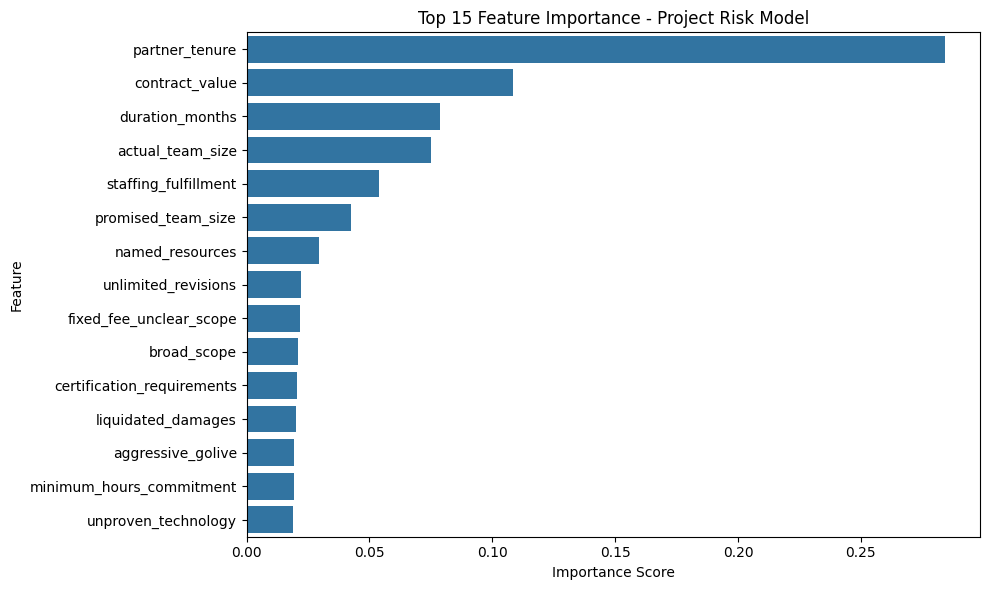

In [23]:
importance = pd.DataFrame({
    "feature": structured_cols,
    "importance": rf_structured.feature_importances_
}).sort_values("importance", ascending=False).head(15)

print(importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x="importance", y="feature")
plt.title("Top 15 Feature Importance - Project Risk Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Summary & Conclusions

### What This Model Demonstrates
This proof of concept demonstrates that project risk in a large
consulting portfolio is measurable and predictable using information
available at contract signing — before a single billable hour is worked.

### The Three Model Comparison
The three-way model comparison produced a clear and actionable finding:

| Model | Accuracy |
|---|---|
| Structured Only | 0.77 |
| Combined | 0.72 |
| TF-IDF Only | 0.61 |

Structured project characteristics outperform contract text analysis
on synthetic data. In a production implementation with real varied
contract text this gap would be expected to close significantly —
a production NLP implementation at a comparable firm successfully
identified predictive contract language from real contract text.

### The Business Case
A model that correctly identifies at-risk projects 77% of the time —
representing a 22 point improvement over random guessing — provides
meaningful early warning capability across a multi-billion dollar
project portfolio. Even modest improvements in early risk identification
translate to significant CoQ reduction at scale.

### The Most Important Finding
Partner tenure is the strongest predictor of project risk with an
importance score of 0.284 — nearly 3x more important than contract
value. This suggests that talent management and partner workload
monitoring represent the highest leverage intervention point available
to a Chief Risk Officer.

### Important Disclaimer
This model was built on synthetic data calibrated to reflect real
world consulting portfolio characteristics. All findings should be
validated against real historical project data before informing
business decisions. The model is intended as a proof of concept
demonstrating the methodology and analytical approach — not as a
production risk management tool.